# Event-TimeRAF Publication-Candidate Results

This notebook reads one manifest-backed final run. It does not train models or alter
predictions. It rejects mixed run identifiers and displays the diagnostics required before
any paper number is updated.


In [1]:
from pathlib import Path, PurePosixPath
import json
import shutil
import sys
import zipfile
import pandas as pd

RESULTS_ROOT_OVERRIDE = None
REQUIRE_FINAL_PUBLICATION_RUN = True
REQUIRE_PUBLICATION_TITLE_ALLOWED = True

def has_project_files(path):
    return (path / 'configs' / 'default.yaml').exists() and (path / 'src' / 'event_timeraf' / 'config.py').exists()

def reset_directory(path):
    path = path.resolve()
    kaggle_working = Path('/kaggle/working').resolve()
    if path.exists():
        if not path.is_relative_to(kaggle_working):
            raise RuntimeError(f'Refusing to refresh non-working directory: {path}')
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)

def locate_results_root():
    if RESULTS_ROOT_OVERRIDE is not None:
        override = Path(RESULTS_ROOT_OVERRIDE).resolve()
        if not has_project_files(override):
            raise FileNotFoundError(f'RESULTS_ROOT_OVERRIDE is missing src/event_timeraf/config.py: {override}')
        return override
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd.parent, Path('/kaggle/working/event_timeraf')]
    kaggle_input = Path('/kaggle/input')
    if kaggle_input.exists():
        candidates.extend(path.parent.parent for path in kaggle_input.rglob('configs/default.yaml'))
    source = next((path for path in candidates if has_project_files(path)), None)
    if source is None and kaggle_input.exists():
        for archive in sorted(kaggle_input.rglob('*.zip')):
            with zipfile.ZipFile(archive) as bundle:
                members = [PurePosixPath(name) for name in bundle.namelist()]
                config_member = next((member for member in members if member.parts[-2:] == ('configs', 'default.yaml')), None)
                package_member = next((member for member in members if member.parts[-3:] == ('src', 'event_timeraf', 'config.py')), None)
                if config_member is None or package_member is None:
                    continue
                if any(member.is_absolute() or '..' in member.parts for member in members):
                    raise RuntimeError(f'Unsafe paths found in attached archive: {archive}')
                extracted = Path('/kaggle/working/event_timeraf_results_source')
                reset_directory(extracted)
                bundle.extractall(extracted)
                source = extracted.joinpath(*config_member.parts[:-2])
                break
    if source is None:
        raise FileNotFoundError('Set RESULTS_ROOT_OVERRIDE to a completed run directory.')
    if kaggle_input.exists() and source.is_relative_to(kaggle_input):
        writable = Path('/kaggle/working/event_timeraf_results')
        writable.mkdir(parents=True, exist_ok=True)
        for directory in ('configs', 'src', 'outputs'):
            if (source / directory).exists():
                target = writable / directory
                if target.exists():
                    shutil.rmtree(target)
                shutil.copytree(source / directory, target)
        return writable
    return source

PROJECT_ROOT = locate_results_root()
PACKAGE_ROOT = PROJECT_ROOT / 'src' / 'event_timeraf'
if not (PACKAGE_ROOT / 'config.py').exists():
    raise FileNotFoundError(f'Package file missing after setup: {PACKAGE_ROOT / "config.py"}')
for module_name in list(sys.modules):
    if module_name == 'event_timeraf' or module_name.startswith('event_timeraf.'):
        del sys.modules[module_name]
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
print({'project_root': str(PROJECT_ROOT), 'package_root': str(PACKAGE_ROOT)})
from event_timeraf.config import load_config
from event_timeraf.plots import plot_horizon_metrics

cfg = load_config(PROJECT_ROOT / 'configs' / 'default.yaml', PROJECT_ROOT)
manifest = json.loads((cfg.paths.outputs / 'logs' / 'run_manifest.json').read_text(encoding='utf-8'))
audit = json.loads((cfg.paths.outputs / 'audit' / 'data_audit.json').read_text(encoding='utf-8'))
metrics = pd.read_csv(cfg.paths.outputs / 'tables' / 'metrics.csv')
predictions = pd.read_parquet(cfg.paths.outputs / 'predictions' / 'predictions.parquet')
explanations = pd.read_parquet(cfg.paths.outputs / 'evidence' / 'explanations.parquet')
ablation = pd.read_csv(cfg.paths.outputs / 'tables' / 'ablation_results.csv')
subset_counts = pd.read_csv(cfg.paths.outputs / 'tables' / 'subset_counts.csv')
drift_results = pd.read_csv(cfg.paths.outputs / 'tables' / 'drift_period_results.csv')
event_results = pd.read_csv(cfg.paths.outputs / 'tables' / 'event_period_results.csv')
stride_results = pd.read_csv(cfg.paths.outputs / 'tables' / 'kb_stride_sensitivity.csv')
stride_models = pd.read_csv(cfg.paths.outputs / 'tables' / 'kb_stride_model_sensitivity.csv')
event_weights = pd.read_csv(cfg.paths.outputs / 'tables' / 'event_weight_sensitivity.csv')
event_composition = pd.read_csv(cfg.paths.outputs / 'tables' / 'event_candidate_composition.csv')
event_category_composition = pd.read_csv(cfg.paths.outputs / 'tables' / 'event_category_candidate_composition.csv')
event_weight_models = pd.read_csv(cfg.paths.outputs / 'tables' / 'event_weight_model_sensitivity.csv')
subset_statistics = pd.read_csv(cfg.paths.outputs / 'tables' / 'subset_target_statistics.csv')
drift_comparison = pd.read_csv(cfg.paths.outputs / 'tables' / 'drift_detector_comparison.csv')
drift_leaf_occupancy = pd.read_csv(cfg.paths.outputs / 'tables' / 'drift_leaf_occupancy.csv')
group_faithfulness = pd.read_csv(cfg.paths.outputs / 'tables' / 'validation_group_faithfulness.csv')
attrition = pd.read_csv(cfg.paths.outputs / 'tables' / 'window_origin_attrition.csv')
horizon_skill = pd.read_csv(cfg.paths.outputs / 'tables' / 'horizon_skill_vs_climatology.csv')
exceedance = pd.read_csv(cfg.paths.outputs / 'tables' / 'aqi_exceedance_metrics.csv')
interval_results = pd.read_csv(cfg.paths.outputs / 'tables' / 'tsfm_interval_metrics.csv')
placebo_validation = pd.read_csv(cfg.paths.outputs / 'tables' / 'tsfm_placebo_fusion_validation.csv')
log_metrics = pd.read_csv(cfg.paths.outputs / 'tables' / 'log_scale_metrics.csv')
quantile_calibration = pd.read_csv(cfg.paths.outputs / 'tables' / 'tsfm_quantile_calibration.csv')
probabilistic_metrics = pd.read_csv(cfg.paths.outputs / 'tables' / 'tsfm_probabilistic_metrics.csv')
neural_training = pd.read_csv(cfg.paths.outputs / 'tables' / 'neural_baseline_training.csv')
feature_control_design = pd.read_csv(cfg.paths.outputs / 'tables' / 'feature_count_control_design.csv')
site_level_sensitivity = pd.read_csv(cfg.paths.outputs / 'tables' / 'site_level_sensitivity.csv')
site_level_design = pd.read_csv(cfg.paths.outputs / 'tables' / 'site_level_design.csv')
site_selection_audit = pd.read_csv(cfg.paths.outputs / 'tables' / 'site_selection_audit.csv')
run_ids = (
    set(metrics['run_id']) | set(predictions['run_id']) | set(explanations['run_id'])
    | set(ablation['run_id']) | set(subset_counts['run_id'])
    | set(drift_results['run_id']) | set(event_results['run_id'])
    | set(stride_results['run_id']) | set(stride_models['run_id'])
    | set(event_weights['run_id']) | set(event_composition['run_id'])
    | set(event_category_composition['run_id'])
    | set(event_weight_models['run_id'])
    | set(subset_statistics['run_id']) | set(drift_comparison['run_id'])
    | set(drift_leaf_occupancy['run_id'])
    | set(group_faithfulness['run_id']) | set(attrition['run_id'])
    | set(horizon_skill['run_id']) | set(exceedance['run_id'])
    | set(interval_results['run_id']) | set(placebo_validation['run_id'])
    | set(log_metrics['run_id']) | set(quantile_calibration['run_id'])
    | set(probabilistic_metrics['run_id']) | set(neural_training['run_id'])
    | set(feature_control_design['run_id'])
    | set(site_level_sensitivity['run_id']) | set(site_level_design['run_id'])
    | set(site_selection_audit['run_id'])
)
if run_ids != {manifest['run_id']}:
    raise RuntimeError(f'Mixed or stale run artifacts detected: {sorted(run_ids)} vs manifest {manifest["run_id"]}')
availability_modes = (
    set(metrics['event_availability_mode']) | set(predictions['event_availability_mode'])
    | set(explanations['event_availability_mode'])
)
if availability_modes != {manifest['run_options']['event_availability_mode']}:
    raise RuntimeError(f'Event-availability metadata mismatch: {sorted(availability_modes)}')
run_options = manifest['run_options']
if REQUIRE_FINAL_PUBLICATION_RUN:
    required_true_options = {
        'require_events': run_options.get('require_events'),
        'final_experiment': run_options.get('final_experiment'),
        'retrieval_evidence_reviewed': run_options.get('retrieval_evidence_reviewed'),
        'run_tsf_model': run_options.get('run_tsf_model'),
        'stride_model_sweep_completed': run_options.get('stride_model_sweep_completed'),
    }
    failed = [name for name, value in required_true_options.items() if value is not True]
    if failed:
        raise RuntimeError(f'Not a final-publication run; failed manifest options: {failed}')
    if not audit.get('core_ready') or not audit.get('event_ready'):
        raise RuntimeError('Final run failed data-readiness gates in data_audit.json')
if run_options.get('primary_kb_stride_hours') != 24:
    raise RuntimeError('Publication-candidate run must use the primary 24-hour knowledge-base stride.')
if run_options.get('drift_score_mode') != 'two_sided':
    raise RuntimeError('Publication-candidate run must use two-sided drift scoring.')
if run_options.get('bootstrap_block_hours', 0) < 168:
    raise RuntimeError('Publication-candidate inference must use blocks of at least 168 origins.')
if run_options.get('bootstrap_resamples', 0) < 2000:
    raise RuntimeError('Publication-candidate inference must use at least 2,000 resamples.')
if not run_options.get('holm_adjustment'):
    raise RuntimeError('Publication-candidate inference must include Holm multiplicity adjustment.')
if set(run_options.get('placebo_fusion_controls', [])) != {'climatology', 'persistence'}:
    raise RuntimeError('Both Chronos fusion placebo controls are required.')
if set(run_options.get('kb_stride_values', [])) != {1, 6, 24}:
    raise RuntimeError('Publication-candidate run must complete 1/6/24-hour KB sensitivity.')
if not run_options.get('journal_baselines_completed'):
    raise RuntimeError('DLinear, LSTM, PatchTST, and LightGBM baselines are required.')
if not run_options.get('event_weight_model_sweep_completed'):
    raise RuntimeError('The learned event-weight sweep is required.')
if not run_options.get('matched_feature_count_control'):
    raise RuntimeError('The matched event-feature-count control is required.')
if not run_options.get('site_level_sensitivity_completed'):
    raise RuntimeError('The three-monitor site-level sensitivity arm is required.')
if REQUIRE_PUBLICATION_TITLE_ALLOWED and not run_options.get('publication_title_allowed'):
    raise RuntimeError('Frozen-TSFM publication gate did not complete; do not use foundation-model title/claims.')
print({
    'run_id': manifest['run_id'],
    'event_availability_mode': run_options['event_availability_mode'],
    'final_experiment': run_options.get('final_experiment'),
    'run_tsf_model': run_options.get('run_tsf_model'),
        'stride_model_sweep_completed': run_options.get('stride_model_sweep_completed'),
    'retrieval_evidence_reviewed': run_options.get('retrieval_evidence_reviewed'),
    'publication_title_allowed': run_options.get('publication_title_allowed'),
})


{'project_root': '/kaggle/working/event_timeraf_results', 'package_root': '/kaggle/working/event_timeraf_results/src/event_timeraf'}
{'run_id': '20260817T110915154675Z', 'event_availability_mode': 'retrospective_event_start', 'final_experiment': True, 'run_tsf_model': True, 'stride_model_sweep_completed': True, 'retrieval_evidence_reviewed': True, 'publication_title_allowed': True}


,run_id,model,subset,event_availability_mode,n_origins,n_points,horizon,mse,mae,rmse,mape,smape,r2
2574,20260817T110915154675Z,C05_lightgbm_context,all,retrospective_event_start,7930,190320,overall,35.475716,3.428440,5.956149,169.195937,31.158172,0.378371
2106,20260817T110915154675Z,M04_xgb_context,all,retrospective_event_start,7930,190320,overall,35.698334,3.458990,5.974808,174.746955,31.416725,0.374470
4446,20260817T110915154675Z,A01_xgb_random_retrieval,all,retrospective_event_start,7930,190320,overall,35.709409,3.458391,5.975735,176.460372,31.405355,0.374276
3744,20260817T110915154675Z,C04_xgb_context_event,all,retrospective_event_start,7930,190320,overall,35.747878,3.465761,5.978953,174.318749,31.464246,0.373602
4914,20260817T110915154675Z,A00_full_without_events,all,retrospective_event_start,7930,190320,overall,35.773600,3.458569,5.981104,174.325242,31.411392,0.373152
3510,20260817T110915154675Z,M07_xgb_cosine,all,retrospective_event_start,7930,190320,overall,35.807077,3.461652,5.983901,179.656625,31.453537,0.372565
4680,20260817T110915154675Z,M09_event_timeraf_full,all,retrospective_event_start,7930,190320,overall,35.870537,3.466188,5.989202,171.441533,31.456990,0.371453
3978,20260817T110915154675Z,A02_xgb_matched_event_placebo,all,retrospective_event_start,7930,190320,overall,35.870691,3.467460,5.989215,174.325178,31.462993,0.371450
4212,20260817T110915154675Z,M08_event_timeraf_no_drift,all,retrospective_event_start,7930,190320,overall,35.978311,3.472462,5.998192,172.697509,31.502427,0.369564
2340,20260817T110915154675Z,C01_ridge_context,all,retrospective_event_start,7930,190320,overall,36.917721,3.567546,6.075995,175.151672,32.577319,0.353103


,run_id,subset,n_origins,eligible_for_metrics
0,20260817T110915154675Z,event,674,True
1,20260817T110915154675Z,non_event,7256,True
2,20260817T110915154675Z,recent_event,426,True
3,20260817T110915154675Z,active_event,567,True
4,20260817T110915154675Z,event_context,425,True
5,20260817T110915154675Z,non_event_context,7505,True
6,20260817T110915154675Z,drift,562,True
7,20260817T110915154675Z,non_drift,7368,True


,run_id,stage_order,stage,count,removed_since_previous,retained_fraction_of_bounded_origins,criterion
0,20260817T110915154675Z,1,source_hourly_rows,58272,0,NaN,Hourly rows in the aligned modeling table
1,20260817T110915154675Z,2,bounded_candidate_origins,58081,191,1.000000,Origins with a complete history/future time bound
2,20260817T110915154675Z,3,chronological_split_eligible,58033,48,0.999174,Targets do not cross split boundaries
3,20260817T110915154675Z,4,complete_lookback,58025,8,0.999036,No missing PM2.5 value in the 168-hour input
4,20260817T110915154675Z,5,complete_observed_target,57881,144,0.996557,All 24 target values are directly observed
5,20260817T110915154675Z,6,complete_origin_features,53682,4199,0.924261,All causal origin features are finite
6,20260817T110915154675Z,7,complete_future_calendar,53682,0,0.924261,All known-future calendar values are finite
7,20260817T110915154675Z,8,retained_windows,53682,0,0.924261,WindowDataset rows used by the experiment


,run_id,subset,n_origins,target_mean,target_variance,climatology_mse,M04_skill_vs_climatology,M09_skill_vs_climatology
0,20260817T110915154675Z,all,7930,10.937164,57.068977,50.975711,0.299699,0.296321
1,20260817T110915154675Z,event,674,12.482575,147.769806,130.495967,0.248486,0.245555
2,20260817T110915154675Z,non_event,7256,10.793614,48.401443,43.589182,0.313941,0.310438
3,20260817T110915154675Z,recent_event,426,13.834987,194.710770,181.589966,0.286581,0.304676
4,20260817T110915154675Z,active_event,567,13.589234,164.599930,150.071393,0.236720,0.232669
5,20260817T110915154675Z,event_context,425,13.801665,195.259460,181.963054,0.286482,0.304410
6,20260817T110915154675Z,non_event_context,7505,10.774951,48.752430,43.558040,0.302826,0.294407
7,20260817T110915154675Z,drift,562,14.604059,187.000534,171.795973,0.333976,0.341389
8,20260817T110915154675Z,non_drift,7368,10.657470,46.054497,41.760050,0.288943,0.282179


,run_id,comparison,comparison_family,metric,difference,ci_low,ci_high,bootstrap_p_value,block_length,resamples,dm_statistic,dm_p_value,dm_hac_lags,bootstrap_p_value_holm,dm_p_value_holm,significant_dm_holm_0_05
0,20260817T110915154675Z,M04_minus_M03_weather_calendar,component_and_placebo_tests,mse,-2.735034,-4.869459,-1.213153,0.007998,168,5000,-2.847365,4.408285e-03,168,0.151970,0.083757,False
1,20260817T110915154675Z,M04_minus_M03_weather_calendar,component_and_placebo_tests,mae,-0.166525,-0.234043,-0.102746,0.000200,168,5000,-5.016312,5.267270e-07,168,0.003799,0.000010,True
2,20260817T110915154675Z,M07_minus_M04_cosine_retrieval,component_and_placebo_tests,mse,0.108743,-0.338879,0.671155,0.671066,168,5000,0.419050,6.751794e-01,168,1.000000,1.000000,False
3,20260817T110915154675Z,M07_minus_M04_cosine_retrieval,component_and_placebo_tests,mae,0.002662,-0.019666,0.026629,0.817437,168,5000,0.225552,8.215496e-01,168,1.000000,1.000000,False
4,20260817T110915154675Z,M08_minus_M07_event_conditioning,component_and_placebo_tests,mse,0.171234,-0.554465,0.824860,0.606279,168,5000,0.486802,6.263984e-01,168,1.000000,1.000000,False
5,20260817T110915154675Z,M08_minus_M07_event_conditioning,component_and_placebo_tests,mae,0.010810,-0.012427,0.040003,0.433913,168,5000,0.788042,4.306722e-01,168,1.000000,1.000000,False
6,20260817T110915154675Z,M09_minus_M08_drift_features,component_and_placebo_tests,mse,-0.107773,-0.399818,0.135473,0.430914,168,5000,-0.783478,4.333463e-01,168,1.000000,1.000000,False
7,20260817T110915154675Z,M09_minus_M08_drift_features,component_and_placebo_tests,mae,-0.006273,-0.013819,0.001265,0.097381,168,5000,-1.653141,9.830211e-02,168,1.000000,1.000000,False
8,20260817T110915154675Z,M09_minus_A00_events,component_and_placebo_tests,mse,0.096937,-0.488644,0.667586,0.727854,168,5000,0.332746,7.393259e-01,168,1.000000,1.000000,False
9,20260817T110915154675Z,M09_minus_A00_events,component_and_placebo_tests,mae,0.007619,-0.016638,0.037425,0.576285,168,5000,0.553575,5.798699e-01,168,1.000000,1.000000,False


,run_id,model,threshold_ug_m3,aggregation,n_origins,observed_exceedances,forecast_exceedances,tp,fp,fn,tn,precision,recall,f1,critical_success_index,specificity,balanced_accuracy,auroc,average_precision
0,20260817T110915154675Z,C00_hour_month_climatology,35.4,24h_forecast_mean,7930,83,0,0,0,83,7847,NaN,0.000000,NaN,0.000000,1.000000,0.500000,0.664462,0.015769
1,20260817T110915154675Z,C00_hour_month_climatology,55.4,24h_forecast_mean,7930,0,0,0,0,0,7930,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN
2,20260817T110915154675Z,C02_calendar_retrieval,35.4,24h_forecast_mean,7930,83,2,0,2,83,7845,0.000000,0.000000,NaN,0.000000,0.999745,0.499873,0.830426,0.039392
3,20260817T110915154675Z,C02_calendar_retrieval,55.4,24h_forecast_mean,7930,0,0,0,0,0,7930,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN
4,20260817T110915154675Z,C03_event_conditioned_retrieval,35.4,24h_forecast_mean,7930,83,17,5,12,78,7835,0.294118,0.060241,0.100000,0.052632,0.998471,0.529356,0.848841,0.180146
5,20260817T110915154675Z,C03_event_conditioned_retrieval,55.4,24h_forecast_mean,7930,0,0,0,0,0,7930,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN
6,20260817T110915154675Z,M00_persistence,35.4,24h_forecast_mean,7930,83,113,30,83,53,7764,0.265487,0.361446,0.306122,0.180723,0.989423,0.675434,0.869687,0.190313
7,20260817T110915154675Z,M00_persistence,55.4,24h_forecast_mean,7930,0,31,0,31,0,7899,0.000000,NaN,NaN,0.000000,0.996091,NaN,NaN,NaN
8,20260817T110915154675Z,M01_daily_seasonal,35.4,24h_forecast_mean,7930,83,85,17,68,66,7779,0.200000,0.204819,0.202381,0.112583,0.991334,0.598077,0.839415,0.206795
9,20260817T110915154675Z,M01_daily_seasonal,55.4,24h_forecast_mean,7930,0,0,0,0,0,7930,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN


,run_id,model,nominal_coverage,empirical_coverage,mean_width,winkler_interval_score,lower_pinball_loss,upper_pinball_loss,n_points
0,20260817T110915154675Z,M10_frozen_chronos,0.8,0.784652,11.148666,17.379255,0.693594,1.044332,190320
1,20260817T110915154675Z,M11_chronos_event_retrieval,0.8,0.646149,8.361503,18.142767,0.760476,1.053800,190320


,run_id,model,transform,n_points,mse,mae,rmse,mape,smape,r2
11,20260817T110915154675Z,C05_lightgbm_context,log1p_nonnegative,190320,0.153388,0.287681,0.391648,59.470190,12.934302,0.433402
9,20260817T110915154675Z,M04_xgb_context,log1p_nonnegative,190320,0.155606,0.290226,0.394470,60.278727,13.040875,0.425208
17,20260817T110915154675Z,A02_xgb_matched_event_placebo,log1p_nonnegative,190320,0.155987,0.290681,0.394951,60.263864,13.056784,0.423803
19,20260817T110915154675Z,A01_xgb_random_retrieval,log1p_nonnegative,190320,0.156099,0.290238,0.395094,60.601060,13.038992,0.423386
15,20260817T110915154675Z,M07_xgb_cosine,log1p_nonnegative,190320,0.156100,0.290612,0.395095,61.065077,13.059987,0.423384
21,20260817T110915154675Z,A00_full_without_events,log1p_nonnegative,190320,0.156329,0.290315,0.395385,60.296790,13.042681,0.422536
16,20260817T110915154675Z,C04_xgb_context_event,log1p_nonnegative,190320,0.156437,0.290762,0.395521,60.241575,13.062835,0.422140
20,20260817T110915154675Z,M09_event_timeraf_full,log1p_nonnegative,190320,0.156604,0.290748,0.395732,59.807105,13.059784,0.421523
26,20260817T110915154675Z,M12_validation_drift_router,log1p_nonnegative,190320,0.156713,0.291169,0.395870,61.338324,13.094468,0.421119
18,20260817T110915154675Z,M08_event_timeraf_no_drift,log1p_nonnegative,190320,0.157019,0.291195,0.396257,60.062164,13.077652,0.419988


,run_id,model,quantile_grid,crps_quantile_approximation,mean_absolute_calibration_error,monotonicity_correction_fraction,n_points
0,20260817T110915154675Z,M10_frozen_chronos,"0.05,0.10,0.15,0.20,0.25,0.30,0.35,0.40,0.45,0...",2.671995,0.011686,0.0,190320
1,20260817T110915154675Z,M11_chronos_event_retrieval,"0.05,0.10,0.15,0.20,0.25,0.30,0.35,0.40,0.45,0...",2.716728,0.059027,0.0,190320


,run_id,model,quantile,empirical_cdf,calibration_error,pinball_loss,n_points
0,20260817T110915154675Z,M10_frozen_chronos,0.05,0.112148,0.062148,0.450308,190320
1,20260817T110915154675Z,M10_frozen_chronos,0.10,0.112148,0.012148,0.693594,190320
2,20260817T110915154675Z,M10_frozen_chronos,0.15,0.157571,0.007571,0.934000,190320
3,20260817T110915154675Z,M10_frozen_chronos,0.20,0.210829,0.010829,1.141709,190320
4,20260817T110915154675Z,M10_frozen_chronos,0.25,0.257057,0.007057,1.316190,190320
5,20260817T110915154675Z,M10_frozen_chronos,0.30,0.306373,0.006373,1.464082,190320
6,20260817T110915154675Z,M10_frozen_chronos,0.35,0.352953,0.002953,1.585251,190320
7,20260817T110915154675Z,M10_frozen_chronos,0.40,0.401067,0.001067,1.682124,190320
8,20260817T110915154675Z,M10_frozen_chronos,0.45,0.448755,-0.001245,1.753934,190320
9,20260817T110915154675Z,M10_frozen_chronos,0.50,0.496170,-0.003830,1.800409,190320


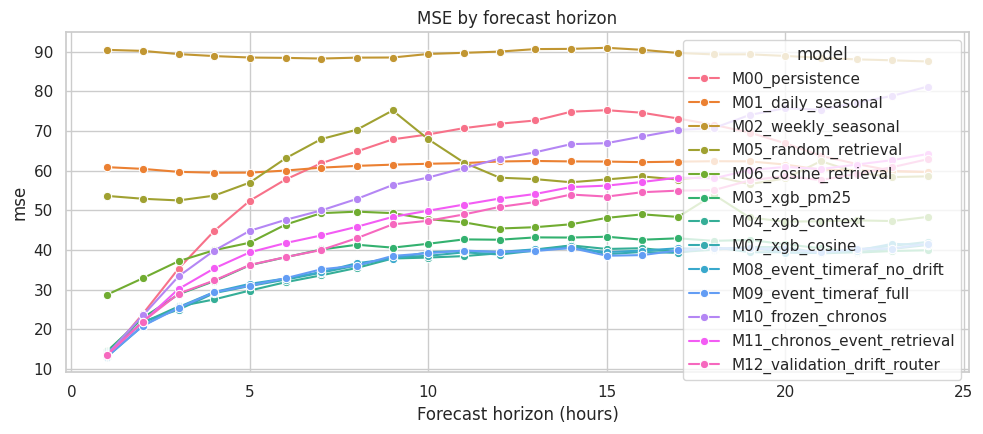

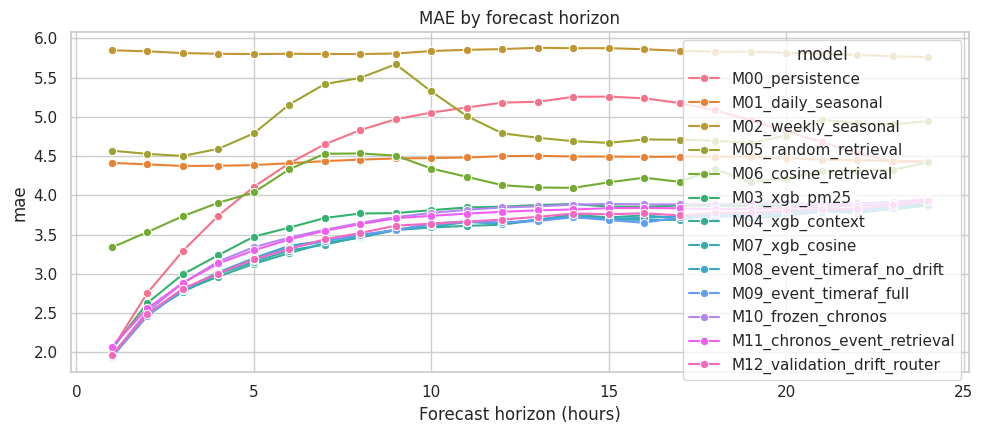

In [2]:
overall = metrics.loc[
    (metrics['horizon'].astype(str) == 'overall') & (metrics['subset'] == 'all')
].sort_values('mse')
display(overall)
primary_metrics = metrics.loc[metrics['model'].str.startswith('M')]
plot_horizon_metrics(primary_metrics, 'mse')
plot_horizon_metrics(primary_metrics, 'mae')
display(subset_counts)
display(attrition)
display(subset_statistics)
display(ablation)
display(exceedance)
display(interval_results)
display(log_metrics.sort_values('mse'))
display(probabilistic_metrics)
display(quantile_calibration)


In [3]:
display(stride_results.sort_values(['method', 'stride_hours']))
display(stride_models.sort_values(['model', 'stride_hours']))
display(event_weights.sort_values(['subset', 'event_weight']))
display(event_composition)
display(event_category_composition)
display(event_weight_models.sort_values(['split', 'event_weight']))
display(placebo_validation.loc[placebo_validation['selected_on_validation']])
display(group_faithfulness.sort_values('mse_increase', ascending=False))
display(horizon_skill.sort_values(['model', 'horizon']))
display(neural_training.loc[neural_training['selected_epoch']])
display(feature_control_design)
display(site_level_design)
display(site_selection_audit)
display(site_level_sensitivity)
display(drift_comparison)
display(drift_leaf_occupancy)
display(drift_results)
display(event_results)
display(explanations.sort_values('drift_score', ascending=False).head(10))


,run_id,stride_hours,method,candidate_count,runtime_seconds,minimum_eligible_candidates,mse,mae,rmse,mape,smape,r2
7,20260817T110915154675Z,1,cosine,37807,149.527440,37807,46.171961,4.203941,6.794995,220.747225,38.176792,0.190945
4,20260817T110915154675Z,6,cosine,6289,60.745048,6289,42.139048,3.981914,6.491460,215.664982,36.289005,0.261612
1,20260817T110915154675Z,24,cosine,1515,0.000005,1515,45.524666,4.165678,6.747197,217.348309,37.871246,0.202287
8,20260817T110915154675Z,1,event_conditioned,37807,149.527440,37807,47.646984,4.212256,6.902680,202.710748,37.446026,0.165098
5,20260817T110915154675Z,6,event_conditioned,6289,60.745048,6289,44.473115,4.064620,6.668817,183.801424,36.174599,0.220713
2,20260817T110915154675Z,24,event_conditioned,1515,0.000005,1515,48.921209,4.270127,6.994370,185.556327,38.203287,0.142770
6,20260817T110915154675Z,1,random,37807,149.527440,37807,58.685387,4.824494,7.660639,247.683365,42.162443,-0.028324
3,20260817T110915154675Z,6,random,6289,60.745048,6289,58.318918,4.823054,7.636682,248.571085,42.139330,-0.021902
0,20260817T110915154675Z,24,random,1515,0.000005,1515,59.812471,4.883344,7.733852,232.202588,42.750419,-0.048073


,run_id,stride_hours,model,mse,mae,rmse,mape,smape,r2
3,20260817T110915154675Z,1,M07_xgb_cosine,35.792049,3.459150,5.982646,182.022301,31.429388,0.372828
0,20260817T110915154675Z,24,M07_xgb_cosine,35.807077,3.461652,5.983901,179.656625,31.453537,0.372565
4,20260817T110915154675Z,1,M08_event_timeraf_no_drift,35.917371,3.451701,5.993110,174.156720,31.322518,0.370632
1,20260817T110915154675Z,24,M08_event_timeraf_no_drift,35.978311,3.472462,5.998192,172.697509,31.502427,0.369564
5,20260817T110915154675Z,1,M09_event_timeraf_full,36.025955,3.457421,6.002163,174.932710,31.365911,0.368730
2,20260817T110915154675Z,24,M09_event_timeraf_full,35.870537,3.466188,5.989202,171.441533,31.456990,0.371453


,run_id,event_weight,subset,n_origins,mse,mae,rmse,mape,smape,r2,selected_candidate_changed_fraction_vs_weight_0
0,20260817T110915154675Z,0.0,all,7930,47.848475,4.246361,6.917259,188.068976,38.095592,0.161568,0.000000
3,20260817T110915154675Z,0.2,all,7930,48.921209,4.270127,6.994370,185.556327,38.203287,0.142770,0.048802
6,20260817T110915154675Z,0.5,all,7930,49.941925,4.286393,7.066960,183.486721,38.285863,0.124885,0.052664
9,20260817T110915154675Z,0.8,all,7930,50.178640,4.293002,7.083688,183.310745,38.285759,0.120737,0.053074
12,20260817T110915154675Z,1.0,all,7930,49.378399,4.291952,7.026977,183.355551,38.381382,0.134759,0.053358
1,20260817T110915154675Z,0.0,event_context,425,127.030865,6.304247,11.270797,649.349705,46.114126,0.349425,NaN
4,20260817T110915154675Z,0.2,event_context,425,147.046824,6.747687,12.126286,602.466635,48.123582,0.246916,NaN
7,20260817T110915154675Z,0.5,event_context,425,166.092195,7.051200,12.887676,563.850221,49.664345,0.149377,NaN
10,20260817T110915154675Z,0.8,event_context,425,170.509011,7.174511,13.057910,560.566723,49.662418,0.126757,NaN
13,20260817T110915154675Z,1.0,event_context,425,155.577460,7.154918,12.473069,561.402749,51.446630,0.203227,NaN


,run_id,event_weight,event_context_queries,conditioned_queries,selected_candidate_event_fraction,event_score_zero_fraction
0,20260817T110915154675Z,0.0,425,425,0.136349,0.255533
1,20260817T110915154675Z,0.2,425,425,0.136349,0.246674
2,20260817T110915154675Z,0.5,425,425,0.136349,0.246059
3,20260817T110915154675Z,0.8,425,425,0.136349,0.246044
4,20260817T110915154675Z,1.0,425,425,0.136349,0.246044


,run_id,category,query_origins_with_category,selected_candidates,selected_candidate_category_fraction,knowledge_base_category_fraction
0,20260817T110915154675Z,wildfire,68,544,0.238971,0.011881
1,20260817T110915154675Z,smoke,0,0,NaN,0.000000
2,20260817T110915154675Z,excessive_heat,0,0,NaN,0.000000
3,20260817T110915154675Z,high_wind,283,2264,0.737191,0.089109
4,20260817T110915154675Z,heavy_rain,136,1088,0.231618,0.006601
5,20260817T110915154675Z,flood,191,1528,0.226440,0.012541
6,20260817T110915154675Z,dust,0,0,NaN,0.000000
7,20260817T110915154675Z,traffic,0,0,NaN,0.000000
8,20260817T110915154675Z,industrial_activity,0,0,NaN,0.000000
9,20260817T110915154675Z,policy,0,0,NaN,0.000000


...

,run_id,detector,threshold,flagged_origins,flag_jaccard
0,20260817T110915154675Z,Event-TimeRAF composite,0.261809,562,0.128168
1,20260817T110915154675Z,KS two-sample,0.433877,996,0.128168


,run_id,model,horizon,state,n_origins,n_trees,occupied_tree_leaf_pairs,mean_same_state_leaf_support,exclusive_assignment_fraction
0,20260817T110915154675Z,M09_event_timeraf_full,1,non_drift,7368,350,13088,2663.076780,0.048684
1,20260817T110915154675Z,M09_event_timeraf_full,1,drift,562,350,9108,114.862979,0.017214
2,20260817T110915154675Z,M09_event_timeraf_full,2,non_drift,7368,350,13567,2427.994252,0.048228
3,20260817T110915154675Z,M09_event_timeraf_full,2,drift,562,350,9388,103.678160,0.019578
4,20260817T110915154675Z,M09_event_timeraf_full,3,non_drift,7368,350,13977,2364.312221,0.049463
5,20260817T110915154675Z,M09_event_timeraf_full,3,drift,562,350,9661,97.411713,0.018607
6,20260817T110915154675Z,M09_event_timeraf_full,4,non_drift,7368,350,13549,2325.164009,0.067792
7,20260817T110915154675Z,M09_event_timeraf_full,4,drift,562,350,9158,105.303894,0.018683
8,20260817T110915154675Z,M09_event_timeraf_full,5,non_drift,7368,350,13898,2268.597650,0.065234
9,20260817T110915154675Z,M09_event_timeraf_full,5,drift,562,350,9308,100.453116,0.019446


,run_id,model,drift_flag,n_origins,n_points,eligible_for_metrics,mse,mae,skill_vs_climatology,event_availability_mode
0,20260817T110915154675Z,C00_hour_month_climatology,False,7368,176832,True,41.760050,4.188940,0.000000,retrospective_event_start
1,20260817T110915154675Z,C02_calendar_retrieval,False,7368,176832,True,48.291839,4.505549,-0.156412,retrospective_event_start
2,20260817T110915154675Z,C03_event_conditioned_retrieval,False,7368,176832,True,40.212126,3.960721,0.037067,retrospective_event_start
3,20260817T110915154675Z,M00_persistence,False,7368,176832,True,47.048052,4.261436,-0.126628,retrospective_event_start
4,20260817T110915154675Z,M01_daily_seasonal,False,7368,176832,True,44.171690,4.126514,-0.057750,retrospective_event_start
5,20260817T110915154675Z,M02_weekly_seasonal,False,7368,176832,True,66.785769,5.369027,-0.599274,retrospective_event_start
6,20260817T110915154675Z,M05_random_retrieval,False,7368,176832,True,48.747598,4.504961,-0.167326,retrospective_event_start
7,20260817T110915154675Z,M06_cosine_retrieval,False,7368,176832,True,38.394348,3.893788,0.080596,retrospective_event_start
8,20260817T110915154675Z,M03_xgb_pm25,False,7368,176832,True,32.305712,3.428241,0.226397,retrospective_event_start
9,20260817T110915154675Z,M04_xgb_context,False,7368,176832,True,29.693764,3.280003,0.288943,retrospective_event_start


,run_id,model,target_event_flag,n_origins,n_points,eligible_for_metrics,mse,mae,skill_vs_climatology,event_availability_mode
0,20260817T110915154675Z,C00_hour_month_climatology,False,7256,174144,True,43.589182,4.210341,0.000000,retrospective_event_start
1,20260817T110915154675Z,C02_calendar_retrieval,False,7256,174144,True,49.531790,4.535133,-0.136332,retrospective_event_start
2,20260817T110915154675Z,C03_event_conditioned_retrieval,False,7256,174144,True,41.335118,3.994909,0.051712,retrospective_event_start
3,20260817T110915154675Z,M00_persistence,False,7256,174144,True,53.974490,4.324520,-0.238254,retrospective_event_start
4,20260817T110915154675Z,M01_daily_seasonal,False,7256,174144,True,54.838349,4.250866,-0.258072,retrospective_event_start
5,20260817T110915154675Z,M02_weekly_seasonal,False,7256,174144,True,74.697300,5.451161,-0.713666,retrospective_event_start
6,20260817T110915154675Z,M05_random_retrieval,False,7256,174144,True,50.275008,4.543700,-0.153383,retrospective_event_start
7,20260817T110915154675Z,M06_cosine_retrieval,False,7256,174144,True,40.474878,3.957942,0.071447,retrospective_event_start
8,20260817T110915154675Z,M03_xgb_pm25,False,7256,174144,True,32.895173,3.426316,0.245336,retrospective_event_start
9,20260817T110915154675Z,M04_xgb_context,False,7256,174144,True,29.904760,3.266909,0.313941,retrospective_event_start


,run_id,window_id,origin_time,explanation,retrieved_evidence_ids,event_evidence_ids,top_feature_effects,drift_components,retrieval_spread,validation_residual_rmse,uncertainty_proxy,drift_score,drift_flag,event_availability_mode
2743,20260817T110915154675Z,w_0052774,2025-01-07 22:00:00+00:00,The mean 24-hour forecast is expected to remai...,"[""w_0018608"", ""w_0028376"", ""w_0012608""]","[""storm_1230323""]","[{""feature"": ""pm25_roll_max_168h"", ""mean_contr...","{""mean_shift"": 1.0, ""variance_shift"": 0.528606...",15.186569,4.569029,15.859001,0.693658,True,retrospective_event_start
2744,20260817T110915154675Z,w_0052775,2025-01-07 23:00:00+00:00,The mean 24-hour forecast is expected to incre...,"[""w_0018608"", ""w_0028376"", ""w_0012608""]","[""storm_1230323""]","[{""feature"": ""pm25_current"", ""mean_contributio...","{""mean_shift"": 1.0, ""variance_shift"": 0.526776...",14.410660,4.569029,15.117643,0.649489,True,retrospective_event_start
2745,20260817T110915154675Z,w_0052776,2025-01-08 00:00:00+00:00,The mean 24-hour forecast is expected to decre...,"[""w_0018608"", ""w_0028376"", ""w_0008432""]","[""storm_1230323""]","[{""feature"": ""pm25_roll_mean_24h"", ""mean_contr...","{""mean_shift"": 1.0, ""variance_shift"": 0.532968...",14.429395,4.569029,15.135503,0.626551,True,retrospective_event_start
2738,20260817T110915154675Z,w_0052769,2025-01-07 17:00:00+00:00,The mean 24-hour forecast is expected to remai...,"[""w_0018608"", ""w_0028376"", ""w_0035792""]","[""storm_1230323""]","[{""feature"": ""pm25_roll_max_168h"", ""mean_contr...","{""mean_shift"": 1.0, ""variance_shift"": 0.555602...",22.420538,4.569029,22.881358,0.621652,True,retrospective_event_start
2748,20260817T110915154675Z,w_0052779,2025-01-08 03:00:00+00:00,The mean 24-hour forecast is expected to decre...,"[""w_0018608"", ""w_0028376"", ""w_0006848""]","[""storm_1230303"", ""storm_1230323""]","[{""feature"": ""pm25_current"", ""mean_contributio...","{""mean_shift"": 0.935238242149353, ""variance_sh...",14.624123,4.569029,15.321259,0.620919,True,retrospective_event_start
2746,20260817T110915154675Z,w_0052777,2025-01-08 01:00:00+00:00,The mean 24-hour forecast is expected to decre...,"[""w_0018608"", ""w_0028376"", ""w_0008432""]","[""storm_1230323""]","[{""feature"": ""pm25_roll_mean_24h"", ""mean_contr...","{""mean_shift"": 1.0, ""variance_shift"": 0.526381...",14.390531,4.569029,15.098457,0.605162,True,retrospective_event_start
2749,20260817T110915154675Z,w_0052780,2025-01-08 04:00:00+00:00,The mean 24-hour forecast is expected to decre...,"[""w_0025424"", ""w_0018608"", ""w_0008432""]","[""storm_1230303"", ""storm_1230323""]","[{""feature"": ""pm25_roll_std_168h"", ""mean_contr...","{""mean_shift"": 0.8913183808326721, ""variance_s...",10.737155,4.569029,11.668870,0.600951,True,retrospective_event_start
2737,20260817T110915154675Z,w_0052768,2025-01-07 16:00:00+00:00,The mean 24-hour forecast is expected to decre...,"[""w_0018608"", ""w_0035792"", ""w_0015968""]","[""storm_1230323""]","[{""feature"": ""pm25_current"", ""mean_contributio...","{""mean_shift"": 1.0, ""variance_shift"": 0.550084...",22.297081,4.569029,22.760401,0.600564,True,retrospective_event_start
2742,20260817T110915154675Z,w_0052773,2025-01-07 21:00:00+00:00,The mean 24-hour forecast is expected to incre...,"[""w_0018608"", ""w_0028376"", ""w_0012608""]","[""storm_1230323""]","[{""feature"": ""pm25_roll_max_168h"", ""mean_contr...","{""mean_shift"": 1.0, ""variance_shift"": 0.533574...",13.608738,4.569029,14.355270,0.590237,True,retrospective_event_start
2747,20260817T110915154675Z,w_0052778,2025-01-08 02:00:00+00:00,The mean 24-hour forecast is expected to remai...,"[""w_0025424"", ""w_0018608"", ""w_0028376""]","[""storm_1230323""]","[{""feature"": ""pm25_roll_max_168h"", ""mean_contr...","{""mean_shift"": 0.9925063848495483, ""variance_s...",14.552757,4.569029,15.253156,0.587495,True,retrospective_event_start
